In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/onurvatansever/ab-test-analysis/refs/heads/main/data/ab_data.csv")
print(df.shape)
df.head(10)

(294480, 5)


,user_id,timestamp,group,landing_page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1
5,936923,20:49.1,control,old_page,0
6,679687,26:46.9,treatment,new_page,1
7,719014,48:29.5,control,old_page,0
8,817355,58:09.0,treatment,new_page,1
9,839785,11:06.6,treatment,new_page,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294480 entries, 0 to 294479
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294480 non-null  int64 
 1   timestamp     294480 non-null  object
 2   group         294480 non-null  object
 3   landing_page  294480 non-null  object
 4   converted     294480 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [19]:
df_encoded = pd.get_dummies(df, columns=['landing_page', 'group'], dtype=int, drop_first=True)
df_encoded

,user_id,timestamp,converted,landing_page_old_page,group_treatment
0,851104,11:48.6,0,1,0
1,804228,01:45.2,0,1,0
2,661590,55:06.2,0,0,1
3,853541,28:03.1,0,0,1
4,864975,52:26.2,1,1,0
...,...,...,...,...,...
294475,734608,45:03.4,0,1,0
294476,697314,20:29.0,0,1,0
294477,715931,40:24.5,0,0,1
294478,759899,20:29.0,0,0,1


In [15]:
df_clean = df_encoded[df_encoded['landing_page_old_page'] != df_encoded['group_treatment']].copy()

df_clean = df_clean.drop_duplicates(subset='user_id', keep='first').reset_index(drop=True)

In [18]:
df_clean

,user_id,timestamp,converted,landing_page_old_page,group_treatment
0,851104,11:48.6,0,1,0
1,804228,01:45.2,0,1,0
2,661590,55:06.2,0,0,1
3,853541,28:03.1,0,0,1
4,864975,52:26.2,1,1,0
...,...,...,...,...,...
290580,945152,51:57.1,0,1,0
290581,734608,45:03.4,0,1,0
290582,697314,20:29.0,0,1,0
290583,715931,40:24.5,0,0,1


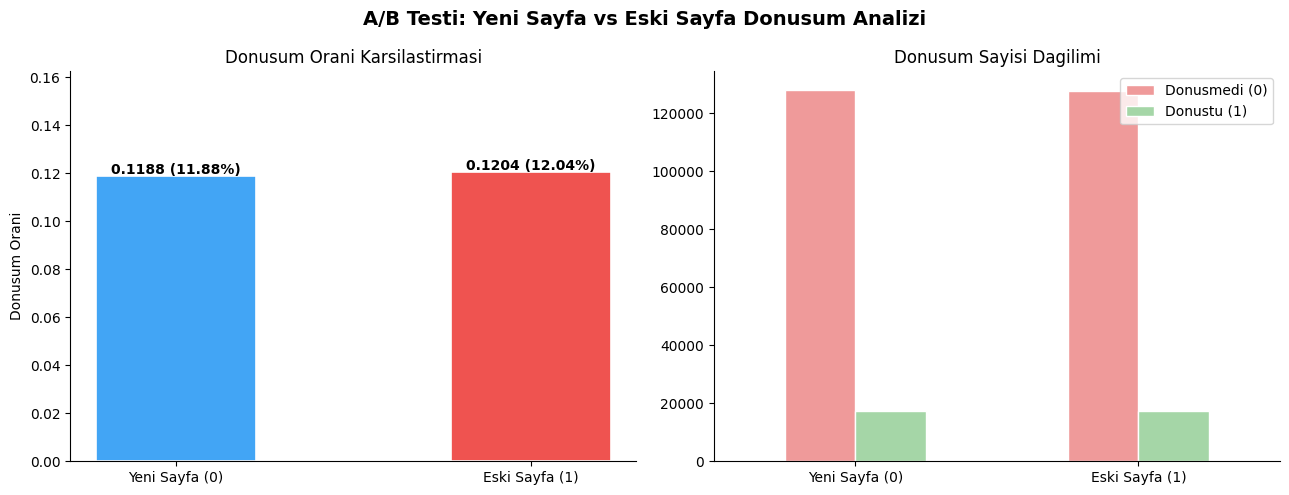

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('A/B Testi: Yeni Sayfa vs Eski Sayfa Donusum Analizi', fontsize=14, fontweight='bold')

rates  = df_clean.groupby('landing_page_old_page')['converted'].mean()
labels = ['Yeni Sayfa (0)', 'Eski Sayfa (1)']
values = [rates[0], rates[1]]
colors = ['#42A5F5', '#EF5350']

bars = axes[0].bar(labels, values, color=colors, width=0.45, edgecolor='white', linewidth=1.2)
axes[0].set_title('Donusum Orani Karsilastirmasi', fontsize=12)
axes[0].set_ylabel('Donusum Orani')
axes[0].set_ylim(0, max(values) * 1.35)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.001,
                 f'{val:.4f} ({val*100:.2f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

counts = df_clean.groupby(['landing_page_old_page', 'converted']).size().unstack()
counts.index = ['Yeni Sayfa (0)', 'Eski Sayfa (1)']
counts.plot(kind='bar', ax=axes[1], color=['#EF9A9A', '#A5D6A7'], edgecolor='white', linewidth=1)
axes[1].set_title('Donusum Sayisi Dagilimi', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Yeni Sayfa (0)', 'Eski Sayfa (1)'], rotation=0)
axes[1].legend(['Donusmedi (0)', 'Donustu (1)'])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
new_page = df_clean[df_clean['landing_page_old_page'] == 0]
old_page = df_clean[df_clean['landing_page_old_page'] == 1]

n_new = len(new_page);  n_old = len(old_page)
c_new = new_page['converted'].sum();  c_old = old_page['converted'].sum()
r_new = c_new / n_new;  r_old = c_old / n_old

z_stat, p_z          = proportions_ztest([c_new, c_old], [n_new, n_old])
contingency          = pd.crosstab(df_clean['landing_page_old_page'], df_clean['converted'])
chi2, p_chi2, dof, _ = stats.chi2_contingency(contingency)

alpha = 0.05

print("=" * 52)
print("       A/B TESTI ISTATISTIKSEL ANALIZ")
print("=" * 52)
print(f"  Yeni Sayfa (0) : {c_new:,} / {n_new:,}  ->  {r_new:.4f} ({r_new*100:.2f}%)")
print(f"  Eski Sayfa (1) : {c_old:,} / {n_old:,}  ->  {r_old:.4f} ({r_old*100:.2f}%)")
print("-" * 52)
print(f"  Z-Testi  : z = {z_stat:.4f}  |  p = {p_z:.6f}")
print(f"  Ki-Kare  : x2 = {chi2:.4f}  |  p = {p_chi2:.6f}")
print("-" * 52)

if p_z < alpha:
    kazanan = 'Yeni Sayfa (0)' if r_new > r_old else 'Eski Sayfa (1)'
    fark = abs(r_new - r_old)
    print(f"  SONUC: Anlamli fark VAR (p < {alpha})")
    print(f"  Kazanan Grup : {kazanan}")
    print(f"  Oran Farki   : {fark:.4f} ({fark*100:.2f} puan)")
else:
    print(f"  SONUC: Anlamli fark YOK (p > {alpha})")
    print("  Iki sayfa arasinda istatistiksel olarak")
    print("  anlamli bir donusum farki bulunamadi.")

print("=" * 52)

       A/B TESTI ISTATISTIKSEL ANALIZ
  Yeni Sayfa (0) : 17,264 / 145,311  ->  0.1188 (11.88%)
  Eski Sayfa (1) : 17,489 / 145,274  ->  0.1204 (12.04%)
----------------------------------------------------
  Z-Testi  : z = -1.3116  |  p = 0.189653
  Ki-Kare  : x2 = 1.7054  |  p = 0.191590
----------------------------------------------------
  SONUC: Anlamli fark YOK (p > 0.05)
  Iki sayfa arasinda istatistiksel olarak
  anlamli bir donusum farki bulunamadi.
